In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

class PINN(nn.Module):
    def __init__(self, layers=[2, 32, 32, 32, 32, 32, 1]):
        super().__init__()
        self.net = nn.Sequential()
        for i in range(len(layers)-2):
            self.net.add_module(f"linear{i}", nn.Linear(layers[i], layers[i+1]))
            #self.net.add_module(f"ReLU{i}", nn.ReLU())
            self.net.add_module(f"tanh{i}", nn.Tanh())
        self.net.add_module("output", nn.Linear(layers[-2], layers[-1]))

    def forward(self, x, t):
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1*1e-4)
n = 1


def exact_solution(r, t):
    # only needed for final error reporting
    return torch.sin(n*t) * r**n
def pde_residual(r, t, model):
    r = r.clone().requires_grad_(True)
    t = t.clone().requires_grad_(True)
    u = model(r, t)

    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_tt = torch.autograd.grad(u_t, t, grad_outputs=torch.ones_like(u_t), create_graph=True)[0]
    u_r = torch.autograd.grad(u, r, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_rr = torch.autograd.grad(u_r, r, grad_outputs=torch.ones_like(u_r), create_graph=True)[0]

    f = r**2 * u_rr + r * u_r +  u_tt
    return f

def boundary(r,t,model):

    r = r.clone().requires_grad_(True)
    u = model(r,t)
    u_r = torch.autograd.grad(u, r, grad_outputs=torch.ones_like(u), create_graph=True)[0]

    g = u_r - n*model(r,t)
    return g
# Choose one fixed interior point (e.g. away from origin and boundary)
r_anchor = torch.tensor([[0.5]], requires_grad=False).to(device)   # shape (1,1)
t_anchor = torch.tensor([[1]], requires_grad=False).to(device)

# Sampling
N_f = 3000   # collocation points inside domain
N_b = 10000   # boundary points in the circumference
for epoch in range(30001):
    model.train()
    optimizer.zero_grad()
    u_anchor = model(r_anchor, t_anchor)
    loss_anchor = torch.mean((u_anchor - 0.5)**2)

    #boundary loss
    r_b = torch.cat([torch.ones(N_b,1)*(1)])
    t_b = torch.rand(N_b, 1)*np.pi*2
    g = boundary(r_b.to(device), t_b.to(device), model)
    loss_b = torch.mean(g**2)

    # PDE loss
    r_f = torch.rand(N_f, 1)
    #r_f = torch.rand(N_f, 1)
    t_f = torch.rand(N_f, 1)*np.pi*2
    f = pde_residual(r_f.to(device), t_f.to(device), model)
    loss_f = torch.mean(f**2)

    loss = loss_b + loss_f + loss_anchor
    loss.backward()
    optimizer.step()
    if epoch % 1000 == 0:
        print(f"Epoch {epoch} | Total Loss: {loss.item():.2e} | BC: {loss_b:.2e} | PDE: {loss_f:.2e}")



torch.save(model.state_dict(), "stekloff.pth")

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0 | Total Loss: 1.52e-01 | BC: 2.18e-02 | PDE: 5.77e-05
Epoch 1000 | Total Loss: 1.45e-02 | BC: 6.17e-03 | PDE: 7.32e-03
Epoch 2000 | Total Loss: 7.86e-03 | BC: 3.87e-03 | PDE: 3.71e-03
Epoch 3000 | Total Loss: 4.97e-03 | BC: 2.51e-03 | PDE: 2.27e-03
Epoch 4000 | Total Loss: 4.07e-03 | BC: 2.00e-03 | PDE: 1.97e-03
Epoch 5000 | Total Loss: 3.51e-03 | BC: 1.86e-03 | PDE: 1.65e-03
Epoch 6000 | Total Loss: 3.02e-03 | BC: 1.34e-03 | PDE: 1.57e-03
Epoch 7000 | Total Loss: 2.51e-03 | BC: 1.11e-03 | PDE: 1.33e-03
Epoch 8000 | Total Loss: 2.30e-03 | BC: 1.00e-03 | PDE: 1.28e-03
Epoch 9000 | Total Loss: 2.08e-03 | BC: 9.25e-04 | PDE: 1.15e-03
Epoch 10000 | Total Loss: 1.79e-03 | BC: 7.61e-04 | PDE: 1.02e-03
Epoch 11000 | Total Loss: 1.61e-03 | BC: 6.25e-04 | PDE: 9.68e-04
Epoch 12000 | Total Loss: 1.52e-03 | BC: 5.17e-04 | PDE: 9.67e-04
Epoch 13000 | Total Loss: 1.29e-03 | BC: 4.40e-04 | PDE: 8.27e-04
Epoch 14000 | Total Loss: 1.04e-03 | BC: 3.42e-04 | PDE: 6.86e-04
Epoch 15000 | Total Los

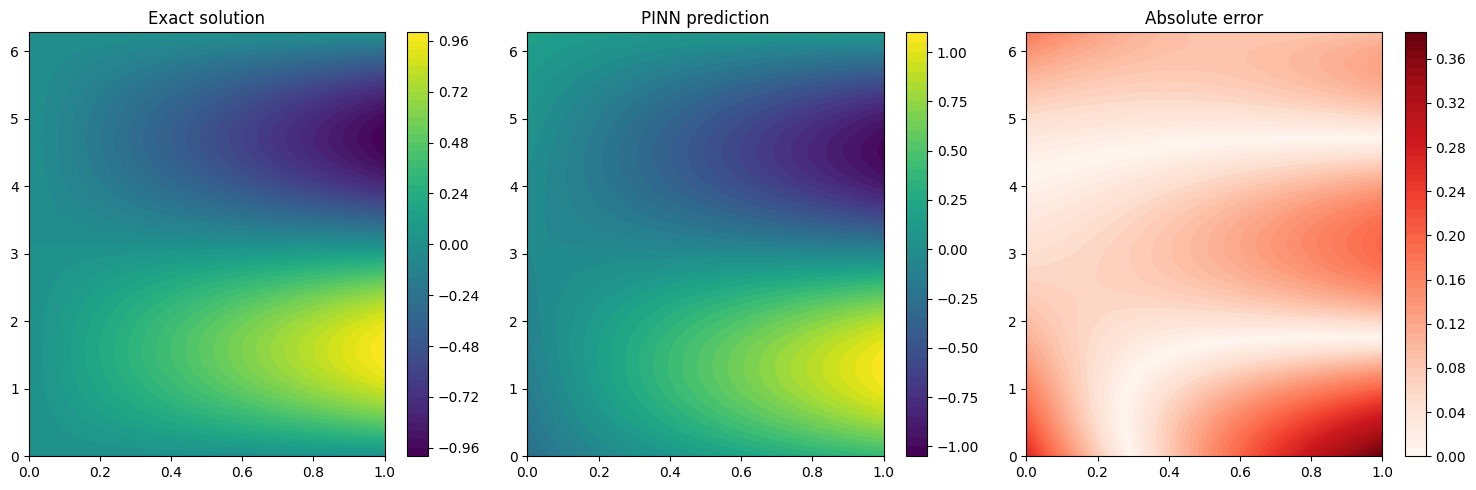

In [3]:
N = 400 # Using N for grid resolution for plotting

# Create a grid of r and t values for plotting
r_vals = torch.linspace(0, 1, N)
t_vals = torch.linspace(0, 2*np.pi, N)

r_grid, t_grid = torch.meshgrid(r_vals, t_vals, indexing='ij')

# Flatten the grid for model input
r_flat = r_grid.flatten().unsqueeze(1).to(device)
t_flat = t_grid.flatten().unsqueeze(1).to(device)

with torch.no_grad():
    # Get PINN prediction
    u_pred_flat = model(r_flat, t_flat)
    u_pred = u_pred_flat.cpu().numpy().reshape(N, N)

# Exact solution
u_exact_flat = exact_solution(r_flat, t_flat)
u_exact = u_exact_flat.cpu().numpy().reshape(N, N)

# Plot
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
im0 = axs[0].contourf(r_grid.cpu().numpy(), t_grid.cpu().numpy(), u_exact, levels=50, cmap='viridis')
axs[0].set_title("Exact solution")
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].contourf(r_grid.cpu().numpy(), t_grid.cpu().numpy(), u_pred, levels=50, cmap='viridis')
axs[1].set_title("PINN prediction")
plt.colorbar(im1, ax=axs[1])

im2 = axs[2].contourf(r_grid.cpu().numpy(), t_grid.cpu().numpy(), np.abs(u_exact - u_pred), levels=50, cmap='Reds')
axs[2].set_title("Absolute error")
plt.colorbar(im2, ax=axs[2])

plt.tight_layout()
plt.savefig("stekloff.png", dpi=200)
plt.show()